In [1]:
import pandas as pd  
import numpy as np 

In [2]:
df = pd.read_csv("./data/seongdong_final.csv")

In [3]:
# import re, time, requests
# import pandas as pd, numpy as np
 
# df1 = pd.read_csv("./data/big_data_set1_2.csv", encoding="cp949") 
# df2 = pd.read_csv("./data/big_data_set2.csv", encoding="cp949")
# df3 = pd.read_csv("./data/big_data_set3.csv", encoding="cp949")

# df1_sd = df1[df1["MCT_BSE_AR"].astype(str).str.contains("성동구", na=False)].copy()

# addr_base = (df1_sd["MCT_BSE_AR"].astype(str)
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True)
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True).str.strip())
# df1_sd["ADDR_QUERY"] = addr_base 

# KEY = "devU01TX0FVVEgyMDI1MDkyMzIyMjI0ODExNjI1ODY=" 
# URL = "https://business.juso.go.kr/addrlink/addrLinkApi.do"

# def juso_lookup(q):
#     p = {"confmKey":KEY, "currentPage":1, "countPerPage":5, "keyword":q, "resultType":"json"}
#     d = requests.get(URL, params=p, timeout=5).json()
#     cand = d.get("results", {}).get("juso", []) or []
#     cand = [c for c in cand if c.get("sggNm") == "성동구"] or cand
#     if not cand:
#         return {"road":"", "jibun":"", "dong":""}
#     j = cand[0]
#     return {"road": j.get("roadAddr",""),
#             "jibun":j.get("jibunAddr",""),
#             "dong": j.get("emdNm","")}

# uniq = df1_sd["ADDR_QUERY"].dropna().unique().tolist()
# res_map = {}
# for i, a in enumerate(uniq, 1):
#     res_map[a] = juso_lookup(a)
#     time.sleep(2) 

# df1_sd["_ROAD_RAW"]  = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("road", ""))
# df1_sd["_JIBUN_RAW"] = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("jibun", ""))
# df1_sd["DONG"]       = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("dong", ""))

# def clean_addr(s):
#     return (s.fillna("").astype(str)
#              .str.replace(r"\s*\([^)]*\)\s*", " ", regex=True)
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True)
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True).str.strip())

# def clean_jibun_to_lot_only(s):
#     base = (s.fillna("").astype(str)
#              .str.replace(r"\s*\([^)]*\)\s*", " ", regex=True)    
#              .str.replace(r"[，,].*$", "", regex=True)         
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True)
#              .str.strip()
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True))
#     pat = re.compile(r'^(.*?\s(?:산\s*)?\d+(?:-\d+)?(?:번지)?)\b')
#     def _cut(x):
#         m = pat.search(x)
#         return m.group(1) if m else x
#     return base.map(_cut)

# cond = df1_sd["_ROAD_RAW"].astype(str).str.len() > 0
# df1_sd["ADDR_ROAD"] = clean_addr(df1_sd["_ROAD_RAW"].where(cond, df1_sd["ADDR_QUERY"]))

# df1_sd["ADDR_JIBUN"] = clean_jibun_to_lot_only(df1_sd["_JIBUN_RAW"])

# def extract_dong_from_any(x):
#     s = "" if pd.isna(x) else str(x)
#     m = re.search(r"성동구\s*([^\s]+동)\b", s)
#     if m: return m.group(1)
#     m = re.search(r"\(([^)]+동)\b", s)
#     return m.group(1) if m else ""

# df1_sd["DONG"] = df1_sd["DONG"].replace("", np.nan)
# df1_sd["DONG"] = df1_sd["DONG"].fillna(df1_sd["_JIBUN_RAW"].map(extract_dong_from_any))
# df1_sd["DONG"] = df1_sd["DONG"].fillna(df1_sd["_ROAD_RAW"].map(extract_dong_from_any))

# df1_sd.drop(columns=["_ROAD_RAW","_JIBUN_RAW","ADDR_QUERY","MCT_BSE_AR"], inplace=True)
# df1_sd.to_csv("./data/set1_update.csv", index=False, encoding="cp949")

In [4]:
# IN_PATH  = os.environ.get("IN_PATH",  "./data/set1_update.csv")
# OUT_PATH = os.environ.get("OUT_PATH", "./data/set1_update_with_coord.csv")
# CACHE    = os.environ.get("CACHE",    "./data/geocode_cache_kakao.json")
# KAKAO_KEY = "28e74d83b10673ec5ffb63b68bad10d6"  

# def make_query(row):
#     for k in ("ADDR_ROAD","ADDR_JIBUN","DONG","ADDR_Q"):
#         v = str(row.get(k, "")).strip() if k in row else ""
#         if v and v.lower()!="nan":
#             if k=="DONG" and not v.startswith("서울특별시"):
#                 return f"서울특별시 성동구 {v}"
#             return v
#     return ""

# def geocode_kakao_addr(q, key):
#     url = "https://dapi.kakao.com/v2/local/search/address.json"
#     headers = {"Authorization": f"KakaoAK {key}"}
#     params  = {"query": q, "analyze_type": "similar", "page": 1, "size": 5}
#     try:
#         r = requests.get(url, headers=headers, params=params, timeout=6)
#         r.raise_for_status()
#         docs = r.json().get("documents", [])
#         if not docs:
#             return None
#         d = docs[0]
#         return {"lat": float(d["y"]),
#                 "lon": float(d["x"]),
#                 "provider": "kakao_addr",
#                 "level": d.get("address_type",""),
#                 "conf": 0.7 if d.get("address_type")=="ROAD_ADDR" else 0.6}
#     except Exception:
#         return None

# def geocode_kakao_keyword(q, key):
#     url = "https://dapi.kakao.com/v2/local/search/keyword.json"
#     headers = {"Authorization": f"KakaoAK {key}"}
#     params  = {"query": q, "page": 1, "size": 5}
#     try:
#         r = requests.get(url, headers=headers, params=params, timeout=6)
#         r.raise_for_status()
#         docs = r.json().get("documents", [])
#         if not docs:
#             return None
#         d = docs[0]
#         return {"lat": float(d["y"]),
#                 "lon": float(d["x"]),
#                 "provider": "kakao_keyword",
#                 "level": "PLACE",
#                 "conf": 0.6}
#     except Exception:
#         return None

# def geocode(q, key):
#     a = geocode_kakao_addr(q, key)
#     if a: return a
#     time.sleep(1)
#     return geocode_kakao_keyword(q, key)

# def main():
#     if not KAKAO_KEY:
#         raise SystemExit("KAKAO_REST_KEY 환경변수가 비어 있습니다.")

#     df = pd.read_csv(IN_PATH, encoding="cp949")
#     if "ADDR_Q" not in df.columns:
#         df["ADDR_Q"] = df.apply(make_query, axis=1)
#     uniq = [q for q in df["ADDR_Q"].dropna().unique().tolist() if q]

#     try:
#         cache = json.load(open(CACHE, "r", encoding="utf-8"))
#     except Exception:
#         cache = {}

#     for i, q in enumerate(uniq, 1):
#         if q not in cache:
#             ans = geocode(q, KAKAO_KEY)
#             if ans is None:
#                 ans = {"lat": None, "lon": None, "provider":"", "level":"", "conf":0.0}
#             cache[q] = ans
#             if i % 30 == 0:
#                 json.dump(cache, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
#             time.sleep(1)
#         if i % 200 == 0:
#             print(f"… processed {i}/{len(uniq)} unique queries")

#     json.dump(cache, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)

#     def get_field(q, k):
#         try: return cache.get(q, {}).get(k, None)
#         except: return None

#     df["LAT"]        = df["ADDR_Q"].map(lambda q: get_field(q, "lat"))
#     df["LON"]        = df["ADDR_Q"].map(lambda q: get_field(q, "lon"))
#     df["GEO_SOURCE"] = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("provider",""))   # kakao_addr / kakao_keyword
#     df["GEO_LEVEL"]  = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("level",""))      # ROAD_ADDR > REGION_ADDR/PLACE (정밀도)
#     df["GEO_CONF"]   = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("conf",0.0))      #    0.7             0.6        (신뢰도)
#     df["GEO_OK"]     = df["LAT"].notna() & df["LON"].notna()                             # 좌표 여부 : T/F 
#     df["GEO_WEAK"]   = df["GEO_CONF"].fillna(0) < 0.5

#     df.to_csv(OUT_PATH, index=False, encoding="cp949")
#     hit = float(df["GEO_OK"].mean()*100)
#     print(f"Saved: {OUT_PATH}  | rows={len(df)}  | geocoding hit = {hit:.1f}%")

# if __name__ == "__main__":
#     main()

In [5]:
# import os, json
# import pandas as pd
# import numpy as np
# from shapely.geometry import shape, Point
# from shapely.strtree import STRtree

# DF_PATH       = "./data/final_df.csv"   
# DONG_GEOJSON  = "./data/administrative_district/4_서울시_행정동/서울_행정동_경계_2017.geojson"
# OUT_CSV       = "./data/seongdong_final.csv"
# TARGET_SIDO   = "서울특별시"
# TARGET_GU     = "성동구"

# os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)

# # 데이터 읽기 
# def read_df_any(path):
#     for enc in ("cp949","utf-8-sig","utf-8"):
#         try:
#             return pd.read_csv(path, encoding=enc, low_memory=False)
#         except Exception:
#             continue
#     raise RuntimeError(f"CSV 읽기 실패: {path}")

# df = read_df_any(DF_PATH)

# # 위/경도 컬럼 자동 인식
# lat_cands = ["위도","lat","LAT","Latitude","latitude","Y","y"]
# lon_cands = ["경도","lon","LON","Longitude","longitude","X","x"]
# def pick(cands, cols):
#     for c in cands:
#         if c in cols: return c
#     return None

# LAT_COL = pick(lat_cands, df.columns)
# LON_COL = pick(lon_cands, df.columns)
# if LAT_COL is None or LON_COL is None:
#     raise ValueError(f"위도/경도 컬럼을 찾을 수 없습니다: {list(df.columns)}")

# pts = df[[LAT_COL, LON_COL]].copy().rename(columns={LAT_COL:"lat", LON_COL:"lon"})
# pts = pts.replace([np.inf,-np.inf], np.nan)
# pts["lat"] = pd.to_numeric(pts["lat"], errors="coerce")
# pts["lon"] = pd.to_numeric(pts["lon"], errors="coerce")

# # 행정동 경계 로드 & 성동구만 필터 
# with open(DONG_GEOJSON, "r", encoding="utf-8") as f:
#     gj = json.load(f)

# features = [ft for ft in gj["features"]
#             if (TARGET_SIDO in ft.get("properties",{}).get("adm_nm",""))
#             and (TARGET_GU   in ft.get("properties",{}).get("adm_nm",""))]

# geoms = [shape(ft["geometry"]) for ft in features]
# props = [ft.get("properties", {}) for ft in features]
# tree  = STRtree(geoms)                    
# id_to_idx = {id(g): i for i,g in enumerate(geoms)}  

# # 포인트 → 행정동 매핑 (버전 호환) 
# adm_full = []; gu_list=[]; dong_list=[]

# for lat, lon in zip(pts["lat"], pts["lon"]):
#     if not (pd.notna(lat) and pd.notna(lon)):
#         adm_full.append(None); gu_list.append(None); dong_list.append(None); 
#         continue

#     p = Point(float(lon), float(lat))  
#     cand = tree.query(p)               

#     # 결과를 '인덱스 리스트'로 정규화
#     idx_list = []
#     if len(cand) > 0:
#         first = cand[0]
#         if isinstance(first, (int, np.integer)):  
#             idx_list = [int(i) for i in np.array(cand).ravel().tolist()]
#         else:                                   
#             idx_list = [id_to_idx[id(g)] for g in cand]

#     matched_idx = None
#     for idx in idx_list:
#         gpoly = geoms[idx]
#         if gpoly.contains(p):                   
#             matched_idx = idx
#             break

#     if matched_idx is None:
#         adm_full.append(None); gu_list.append(None); dong_list.append(None)
#     else:
#         nm = props[matched_idx].get("adm_nm","")
#         toks = str(nm).split()
#         gname = toks[1] if len(toks) >= 2 else ""
#         dname = toks[-1] if len(toks) >= 3 else ""
#         adm_full.append(nm); gu_list.append(gname); dong_list.append(dname)

# df_out = df.copy()
# df_out["adm_nm_full"] = adm_full
# df_out["자치구"] = gu_list
# df_out["행정동"] = dong_list

# df_out.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

In [6]:
# 업종 중분류 분리
MIDMAP = {# 한식
          "한식-육류/고기":"한식",    "백반/가정식":"한식",    "한정식":"한식",    
          "한식-해물/생선":"한식",    "한식-감자탕":"한식",    "한식뷔페":"한식",  
          "한식-찌개/전골":"한식",    "한식-냉면":"한식",      "기사식당":"한식",
          "한식-국수/만두":"한식",    "한식-죽":"한식",        "한식-두부요리":"한식",
          "한식-단품요리일반":"한식", "한식-국밥/설렁탕":"한식",
           
          # 간편식/분식/도시락
          "분식":"간편식", "도시락":"간편식", "샌드위치/토스트":"간편식", 

          # 양식/서양
          "양식":"양식/서양", "스테이크":"양식/서양",

          # 패스트푸드 
          "치킨":"패스트푸드", "피자":"패스트푸드", "햄버거":"패스트푸드",  

          # 일식
          "일식당":"일식",             "일식-초밥/롤":"일식",     "일식-참치회":"일식",
          "일식-우동/소바/라면":"일식", "일식-덮밥/돈가스":"일식", "일식-샤브샤브":"일식", 
  
          # 중식
          "중식당":"중식", "중식-훠궈/마라탕":"중식", "중식-딤섬/중식만두":"중식",

          # 아시아/세계
          "동남아/인도음식":"아시아/세계", "기타세계요리":"아시아/세계",

          # 주점/주류(업장)
          "포장마차":"주점/주류업장",  "이자카야":"주점/주류업장",      "호프/맥주":"주점/주류업장",    
          "요리주점":"주점/주류업장",  "꼬치구이":"주점/주류업장",      "와인바":"주점/주류업장",
          "민속주점":"주점/주류업장",  "일반 유흥주점":"주점/주류업장",  "룸살롱/단란주점":"주점/주류업장",
 
          # 카페/음료
          "카페":"카페/음료",  "커피전문점":"카페/음료",  "테이크아웃커피":"카페/음료", 
          "주스":"카페/음료",  "차":"카페/음료",         "테마카페":"카페/음료", 

          # 디저트/베이커리
          "베이커리":"디저트/베이커리",  "와플/크로플":"디저트/베이커리",  "아이스크림/빙수":"디저트/베이커리",
          "도너츠":"디저트/베이커리",    "탕후루":"디저트/베이커리",  
          "마카롱":"디저트/베이커리",    "떡/한과":"디저트/베이커리",      

          # 단체급식/푸드코트
          "구내식당/푸드코트":"단체급식/푸드코트", 
          
          # 반찬/테이크아웃
          "반찬": "반찬/테이크아웃",

          # 식품/식자재 소매
          "축산물":"식품소매",  "식료품":"식품소매",    "농산물":"식품소매",    "청과물":"식품소매",
          "수산물":"식품소매",  "건어물":"식품소매",    "미곡상":"식품소매",    "유제품":"식품소매", 

          # 주류/와인샵(소매)
          "와인샵":"주류소매",  "주류":"주류소매",  "담배":"담배소매",

          # 건강/특수식품
          "인삼제품":"건강식품/건강원", "건강식품":"건강식품/건강원", "건강원":"건강식품/건강원",

          # 제조/기타
          "식품 제조":"식품제조",  "떡/한과 제조":"식품제조",  "None":"None"}

df["업종중분류"] = df["업종"].map(MIDMAP).fillna("기타(미정)")

EXCLUDE_MIDS = {"주류소매","담배소매","식품제조","건강식품/건강원"}
df = df[~df["업종중분류"].isin(EXCLUDE_MIDS)].reset_index(drop=True)

In [7]:
def ym_to_dt(ym):
    ym = ym.astype(str).str.zfill(6)
    return pd.to_datetime(ym + "01", format="%Y%m%d", errors="coerce")

def ymd_float_to_dt(s):
    s_num = pd.to_numeric(s, errors="coerce")        
    s_str = s_num.dropna().astype(np.int64).astype(str).str[:8]
    out = pd.Series(pd.NaT, index=s.index)
    out.loc[s_str.index] = pd.to_datetime(s_str, format="%Y%m%d", errors="coerce")
    return out

def month_diff(d1, d2):
    y1, m1 = d1.dt.year, d1.dt.month
    y2, m2 = d2.dt.year, d2.dt.month
    return (y2 - y1) * 12 + (m2 - m1)

df = df.copy()

# 날짜 파싱
df["dt"] = ym_to_dt(df["기준년월"])
df["open_dt"] = ymd_float_to_dt(df["개설일"])
df["close_dt"] = ymd_float_to_dt(df["폐업일"])

# 운영개월수/해당월 폐업 여부
df["tenure_m"] = month_diff(df["open_dt"], df["dt"]).clip(lower=0)
df["is_closed_this_month"] = (df["close_dt"].dt.to_period("M") == df["dt"].dt.to_period("M")).astype(int)

# 연/월/분기 
df["year"] = df["dt"].dt.year.astype("Int16")
df["month"] = df["dt"].dt.month.astype("Int8")
df["quarter"]= df["dt"].dt.quarter.astype("Int8")

# 계절 라벨 (winter/spring/summer/autumn)
season_map = {12:"winter", 1:"winter", 2:"winter", 3:"spring", 4:"spring", 5:"spring",
               6:"summer", 7:"summer", 8:"summer", 9:"autumn",10:"autumn",11:"autumn"}

df["season"] = pd.Categorical(df["month"].map(season_map), categories=["winter","spring","summer","autumn"])

In [8]:
SENTINEL = -999_999.9

def replace_sentinel_with_nan(df, cols=None, also_clip_percent=True):
    out = df.copy()
    target_cols = cols if cols is not None else list(out.columns)

    for c in target_cols:
        s_num = pd.to_numeric(out[c], errors="coerce")
        if (s_num == SENTINEL).any():
            out[c] = s_num.mask(s_num == SENTINEL)
        else:
            if out[c].astype(str).str.contains(r"-?999999\.9$", na=False).any():
                out[c] = s_num.mask(s_num == SENTINEL)
            else:
                if s_num.notna().sum() > 0:
                    out[c] = s_num
        if also_clip_percent and any(k in c for k in ["비율", "비중", "순위 비율"]):
            out[c] = pd.to_numeric(out[c], errors="coerce")
            out[c] = out[c].mask(~out[c].between(0, 100))
            out[c] = out[c].clip(0, 100)

    return out

df = replace_sentinel_with_nan(df)

In [9]:
# 고객 연령구성/유입 경로 다양성(엔트로피)
male_cols = ["남성 20대이하 고객 비중","남성 30대 고객 비중","남성 40대 고객 비중","남성 50대 고객 비중","남성 60대이상 고객 비중"]
fem_cols = ["여성 20대이하 고객 비중","여성 30대 고객 비중","여성 40대 고객 비중","여성 50대 고객 비중","여성 60대이상 고객 비중"]
age_cols = male_cols + fem_cols
inflow_cols = ["거주 이용 고객 비율","직장 이용 고객 비율","유동인구 이용 고객 비율"]

def entropy_row(vals):
    p = np.clip(np.array(vals, dtype=float), 0, 1)
    s = p.sum()
    if s <= 0: 
        return 0.0
    p = p / s
    p = np.where(p>0, p, 1)
    return -np.sum(p * np.log(p))

df["cust_age_entropy"] = df[age_cols].apply(entropy_row, axis=1)
df["cust_source_entropy"] = df[inflow_cols].apply(entropy_row, axis=1)

In [10]:
# # 재방문 고객 비중 : 전월 변화 + 3개월 평균
# df = df.sort_values(["가맹점번호","dt"])

# den = (df["신규 고객 비중"] + df["재방문 고객 비중"])
# df["share_new"] = (df["재방문 고객 비중"] / den).where(den > 1e-9)  
# df["share_new_lag1"] = df.groupby("가맹점번호")["share_new"].shift(1)
# df["share_new_chg1"] = df["share_new"] - df["share_new_lag1"]
# df["share_new_roll3"] = df.groupby("가맹점번호")["share_new"].transform(lambda x: x.rolling(3,1).mean())

In [11]:
# # 시계열 추세/변동성 피처 (lag, 변화량, 3개월 이동평균/표준편차)
# time_vars = ["동일업종 매출금액 비율","동일업종 매출건수 비율","동일업종 매출순위 비율","동일상권 매출순위 비율",
#              "동일업종 해지가맹점 비중","동일상권 해지가맹점 비중","재방문 고객 비중","신규 고객 비중",
#              "거주 이용 고객 비율","직장 이용 고객 비율","유동인구 이용 고객 비율","배달매출금액 비율"]

# df = df.sort_values(["가맹점번호","dt"])
# for c in time_vars:
#     if c not in df.columns: 
#         continue
#     df[f"{c}_lag1"] = df.groupby("가맹점번호")[c].shift(1)
#     df[f"{c}_chg1"] = df[c] - df[f"{c}_lag1"]
#     df[f"{c}_roll3_mean"] = df.groupby("가맹점번호")[c].transform(lambda x: x.rolling(3, min_periods=1).mean())
#     df[f"{c}_roll3_std"]  = df.groupby("가맹점번호")[c].transform(lambda x: x.rolling(3, min_periods=2).std()).fillna(0)

In [12]:
# # 피어(중분류×행정동×월) 대비 상대위치
# peer_keys = ["업종중분류","행정동","dt"]
# peer_vars = ["동일업종 매출순위 비율","동일상권 매출순위 비율","재방문 고객 비중","신규 고객 비중",
#              "거주 이용 고객 비율","직장 이용 고객 비율","유동인구 이용 고객 비율"]

# for c in peer_vars:
#     if c not in df.columns: 
#         continue
#     grp = df.groupby(peer_keys)[c]
#     df[f"{c}_peer_mean"] = grp.transform("mean")
#     df[f"{c}_peer_std"]  = grp.transform("std").replace(0, np.nan)
#     df[f"{c}_gap_peer"]  = df[c] - df[f"{c}_peer_mean"]
#     df[f"{c}_z_in_peer"] = df[f"{c}_gap_peer"] / df[f"{c}_peer_std"]

In [13]:
# 해지 20% 초과 비율(3개월) - 해지 압력
def pressure_flag(s, thr=0.2):
    over = (s > thr).astype(int)
    return over.rolling(3, min_periods=1).sum()

for c in ["동일업종 해지가맹점 비중","동일상권 해지가맹점 비중"]:
    if c in df.columns:
        df[f"{c}_press3"] = df.groupby("가맹점번호")[c].transform(lambda x: pressure_flag(x, 0.2))

In [14]:
# 경쟁 밀도(반경 200m 내 점포 수)
from sklearn.neighbors import BallTree

RADIUS_M = 500                           # 반경(m)
EARTH_R = 6371.0                         # km
RAD = np.deg2rad
RADIUS_RAD = (RADIUS_M / 1000) / EARTH_R # 라디안 반경

# 좌표/키 정리 
need = {"dt","가맹점번호","업종중분류","위도","경도"}
assert need.issubset(df.columns), f"필수 컬럼 누락: {need - set(df.columns)}"
df2 = df.dropna(subset=["위도","경도"]).copy()

# 월별 스냅샷: (dt, 가맹점번호) 중복 제거 → 점포당 월 1행만
snap = (df2.sort_values(["dt","가맹점번호"]).drop_duplicates(["dt","가맹점번호"])
            [["dt","가맹점번호","업종중분류","위도","경도"]].reset_index(drop=True))

snap["near_all_500m"] = 0
snap["near_same_mid_500m"] = 0

# 월별로 BallTree로 반경 이웃 계산 
for (t,), sub in snap.groupby(["dt"], dropna=False):
    idx = sub.index
    XY = np.c_[RAD(sub["위도"].to_numpy()), RAD(sub["경도"].to_numpy())]  # 라디안
    mids = sub["업종중분류"].to_numpy()

    if len(sub) == 1:
        # 이 달에 점포가 1곳뿐이면 모두 0
        snap.loc[idx, ["near_all_500m","near_same_mid_200m"]] = 0
        continue

    tree = BallTree(XY, metric="haversine")
    neigh = tree.query_radius(XY, r=RADIUS_RAD, return_distance=False)  # 각 점포의 이웃 인덱스(자기 포함)

    all_counts  = np.fromiter((len(ix) - 1 for ix in neigh), dtype=int)
    same_counts = np.fromiter(((mids[i] == mids[ix]).sum() - 1 for i, ix in enumerate(neigh)), dtype=int)

    snap.loc[idx, "near_all_500m"] = all_counts
    snap.loc[idx, "near_same_mid_500m"] = same_counts

# 비율(0으로 나누기 방지)
den = snap["near_all_500m"].replace(0, np.nan)
snap["near_same_to_all"] = (snap["near_same_mid_500m"] / den).fillna(0.0)

df = df.merge(snap[["dt","가맹점번호","near_all_500m","near_same_mid_500m","near_same_to_all"]],
              on=["dt","가맹점번호"], how="left")

In [15]:
# feat_cols = ["cust_age_entropy","cust_source_entropy","share_new","share_new_chg1","share_new_roll3",
#              "동일업종 해지가맹점 비중_press3","동일상권 해지가맹점 비중_press3","near_all_200m","near_same_mid_200m",
#              "near_same_to_all"] + [c for c in df.columns if c.endswith(("_gap_peer","_z_in_peer","_roll3_mean",
#                                                                          "_roll3_std","_chg1","_lag1"))]

# X = df[feat_cols].select_dtypes(include=[np.number])

# summary = pd.DataFrame({"missing_rate": X.isna().mean(),"n_unique": X.nunique(),"std": X.std(),
#                        }).sort_values(["missing_rate","std"], ascending=[False, True])

# print(summary.head(50))  

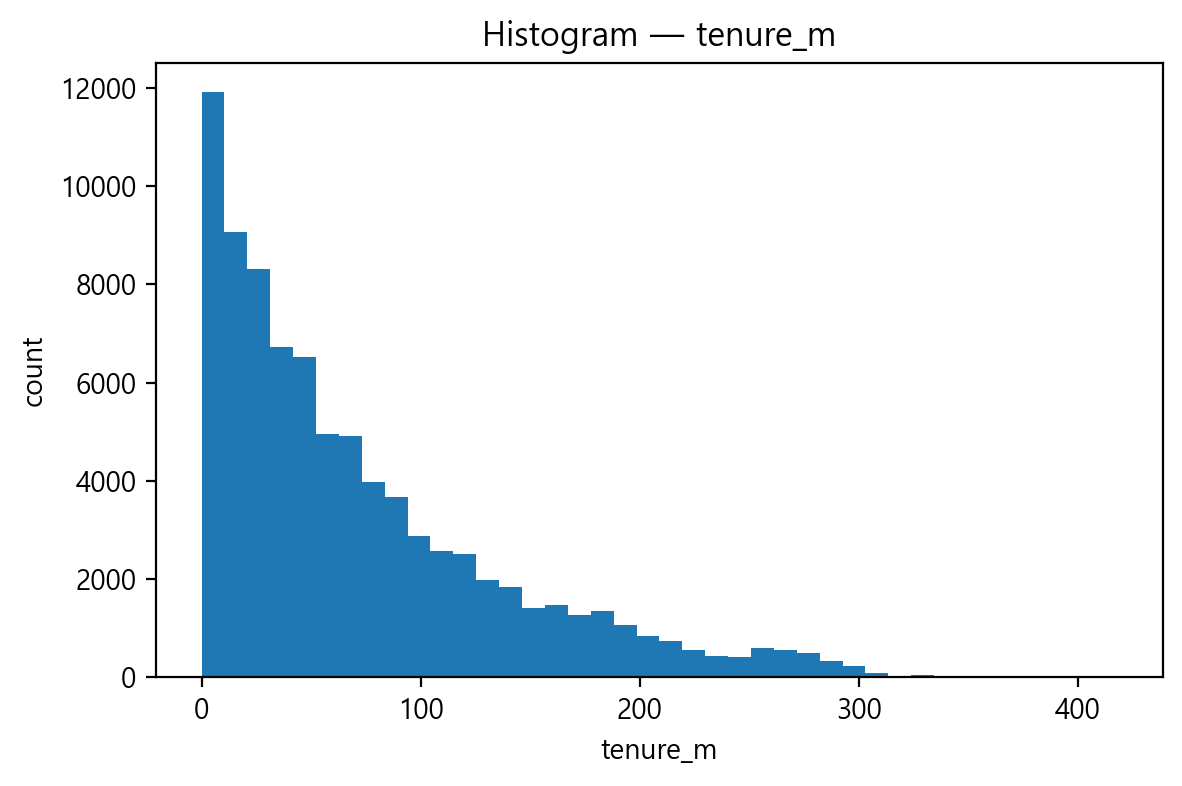

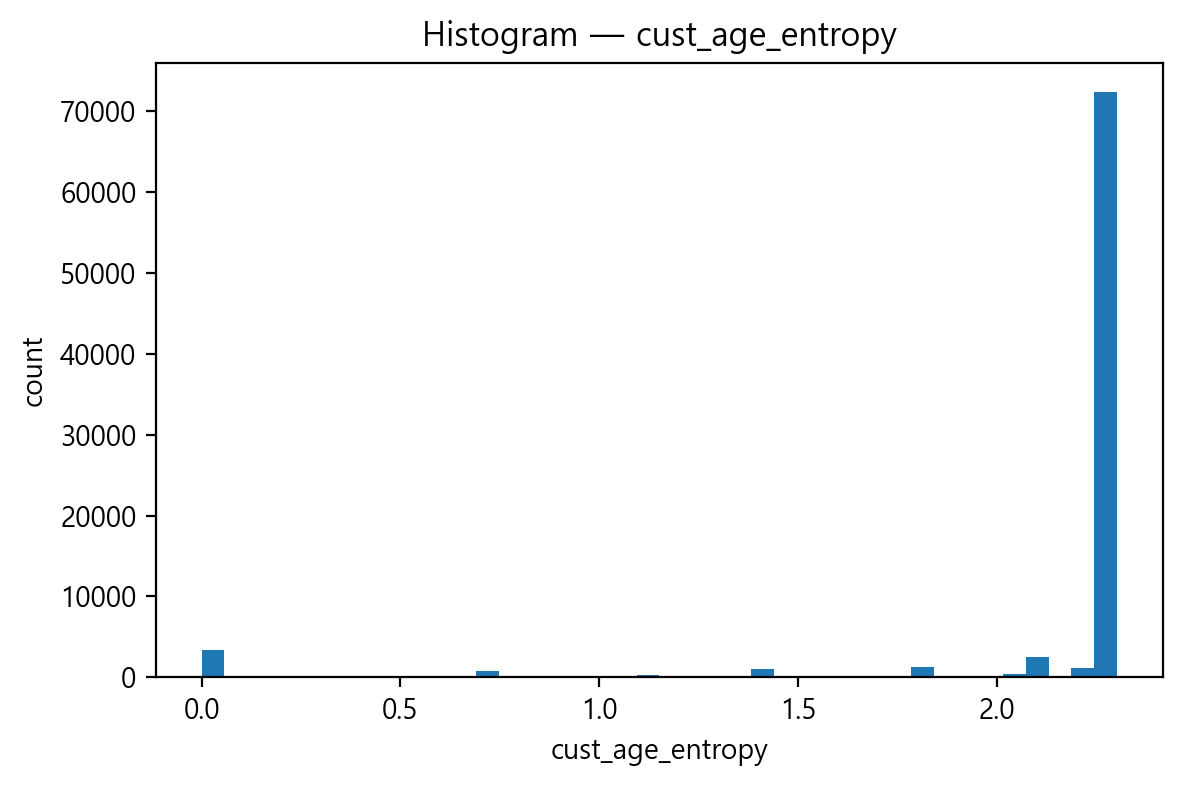

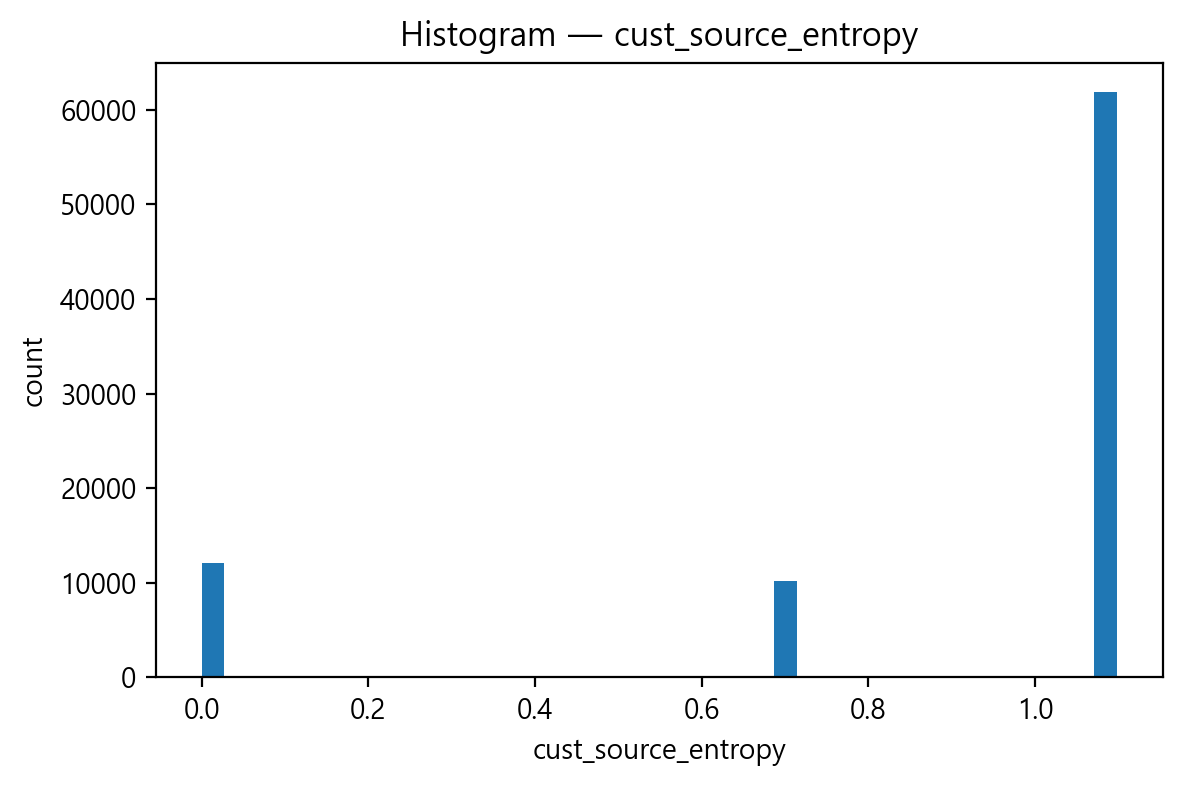

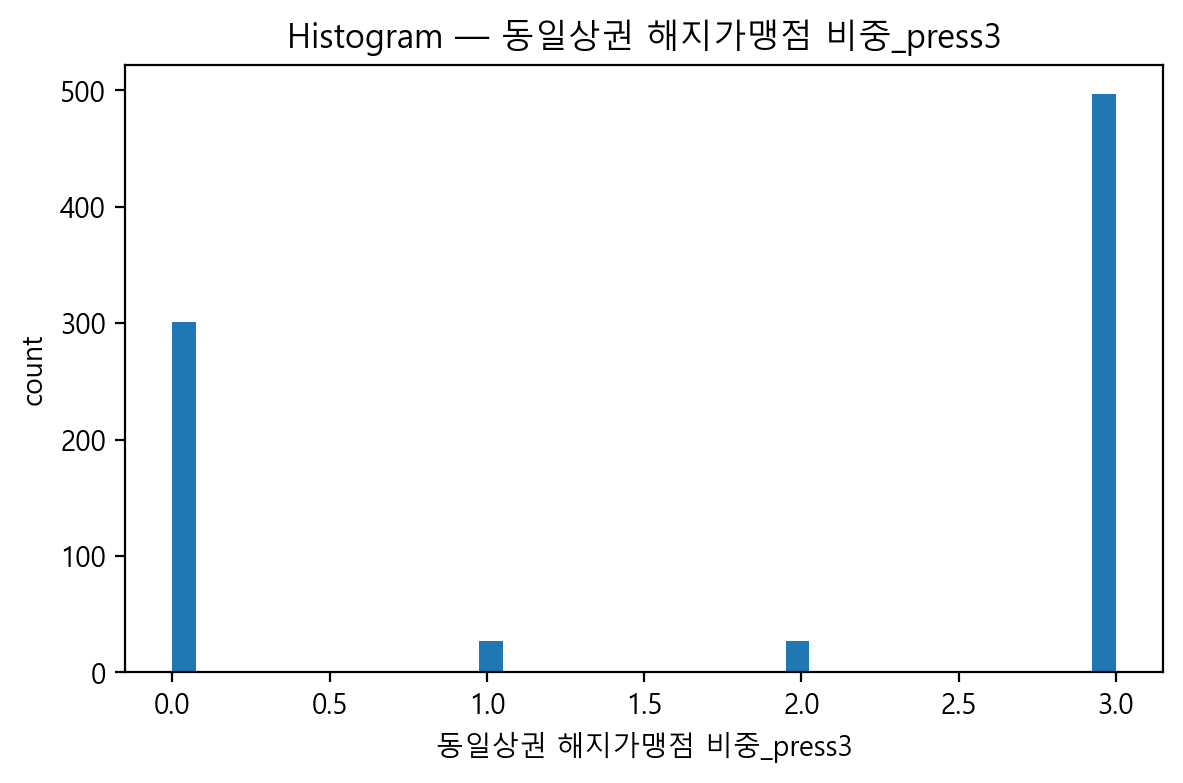

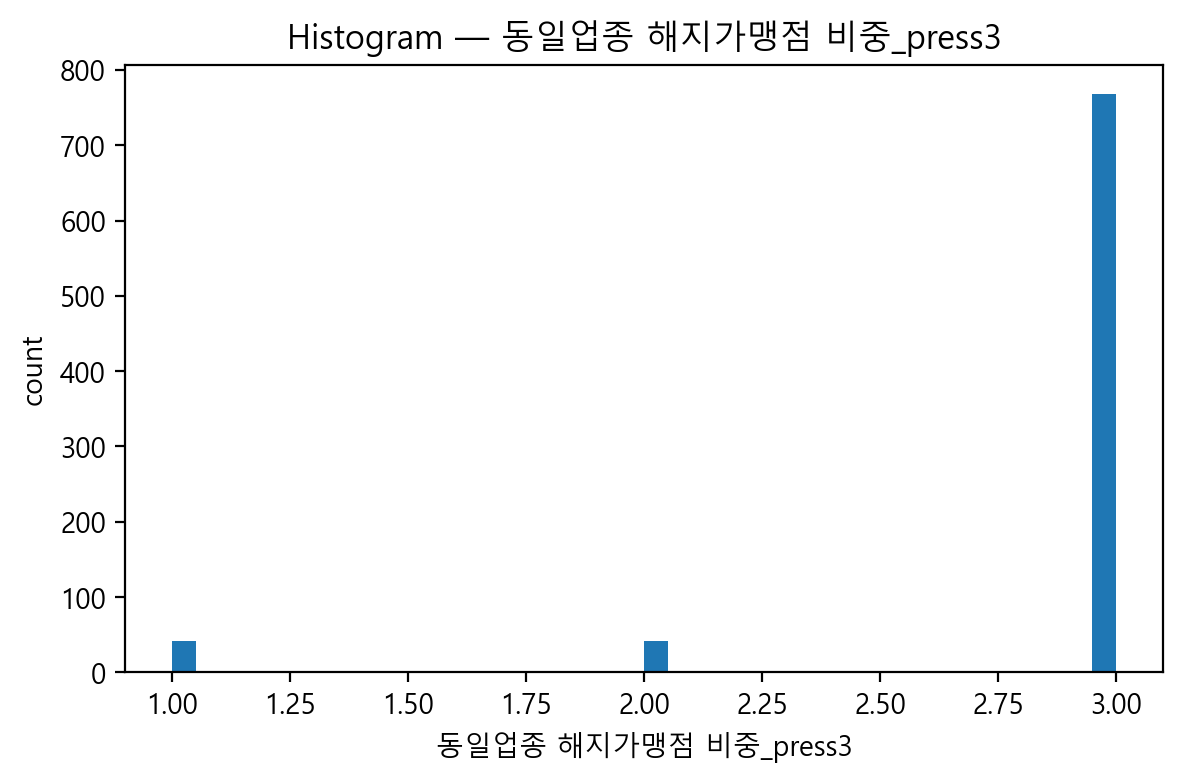

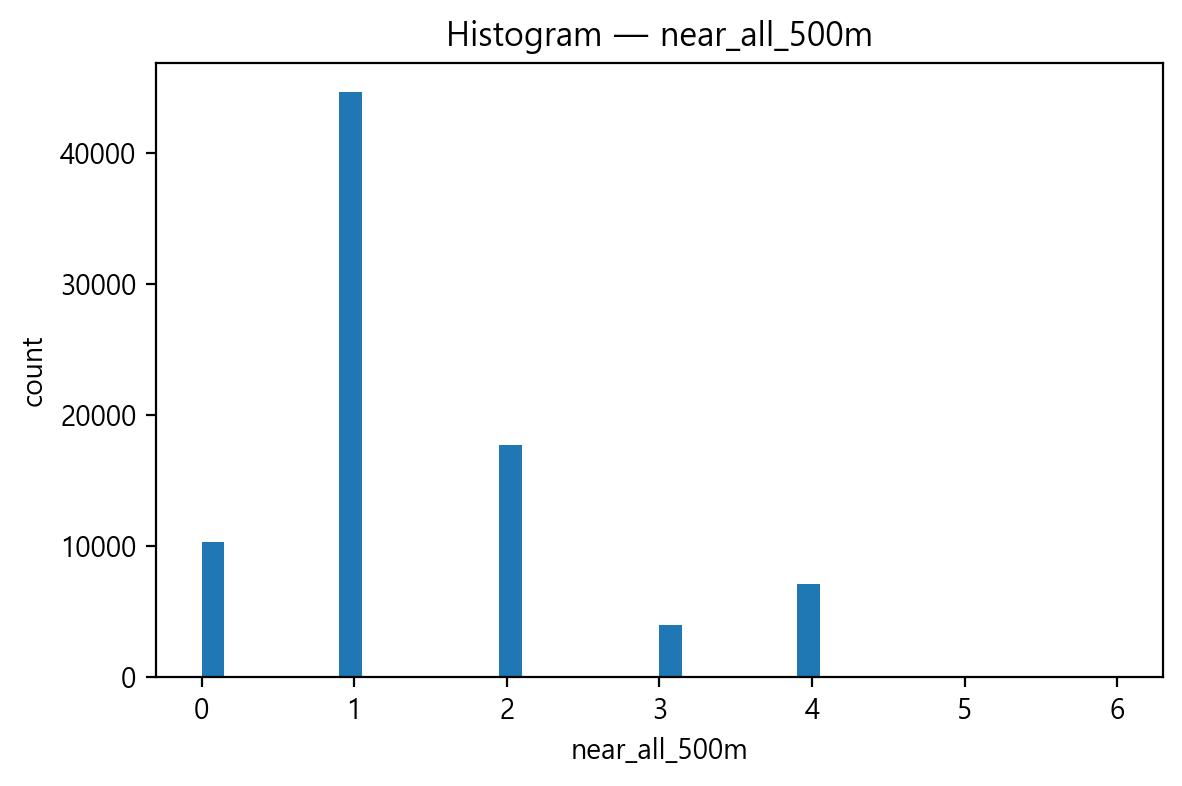

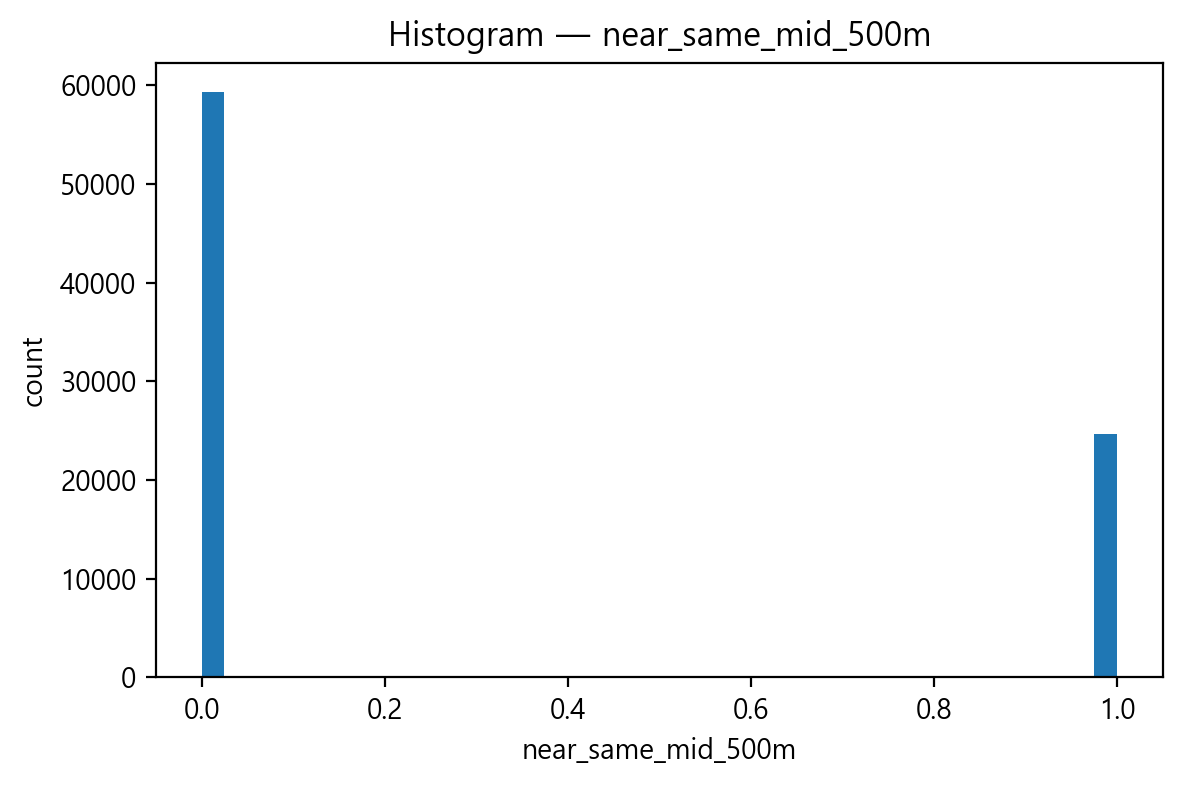

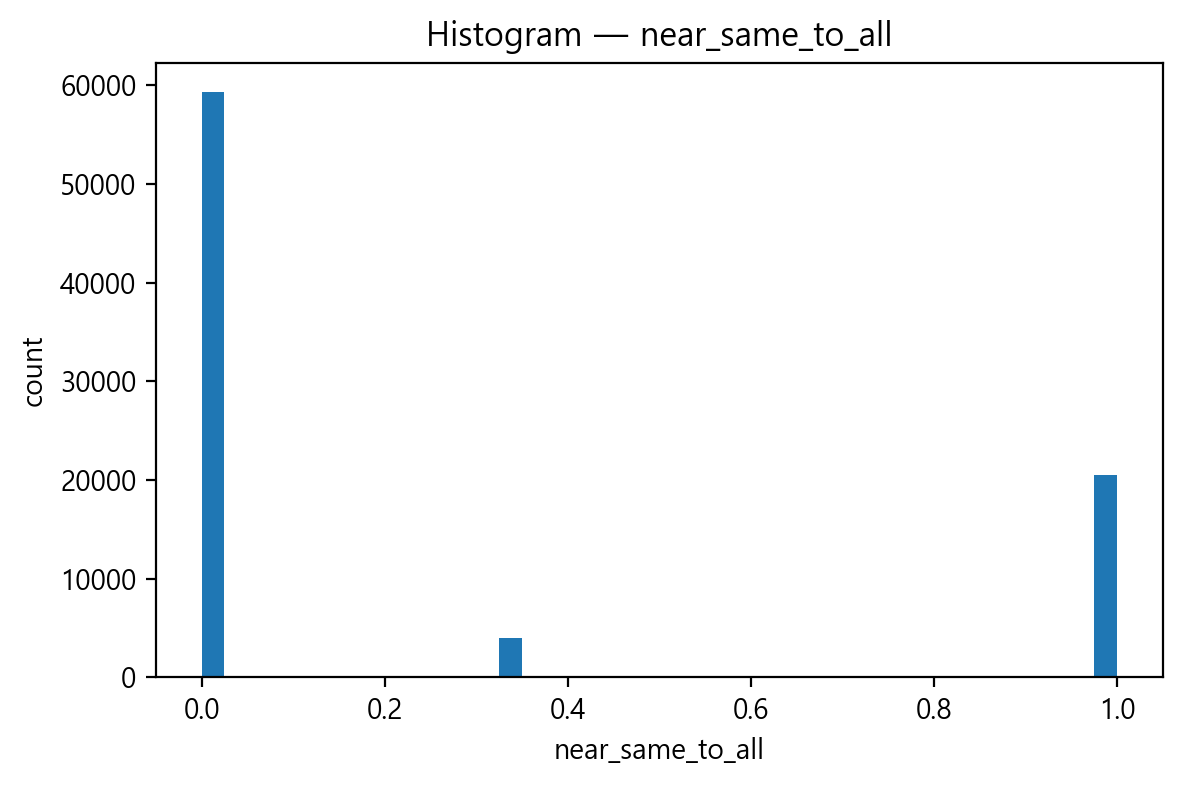

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

cols = ["tenure_m", "month", "season", "cust_age_entropy", "cust_source_entropy",
        "동일상권 해지가맹점 비중_press3", "동일업종 해지가맹점 비중_press3",
        "near_all_500m", "near_same_mid_500m", "near_same_to_all"]

# 히스토그램 (수치형)
num_cols = ["tenure_m", "cust_age_entropy", "cust_source_entropy",
            "동일상권 해지가맹점 비중_press3", "동일업종 해지가맹점 비중_press3",
            "near_all_500m", "near_same_mid_500m", "near_same_to_all"]
for c in [x for x in num_cols if x in df.columns]:
    plt.figure(figsize=(6,4))
    plt.hist(pd.to_numeric(df[c], errors='coerce').dropna(), bins=40)
    plt.title(f"Histogram — {c}")
    plt.xlabel(c); plt.ylabel("count")
    plt.tight_layout(); plt.show()

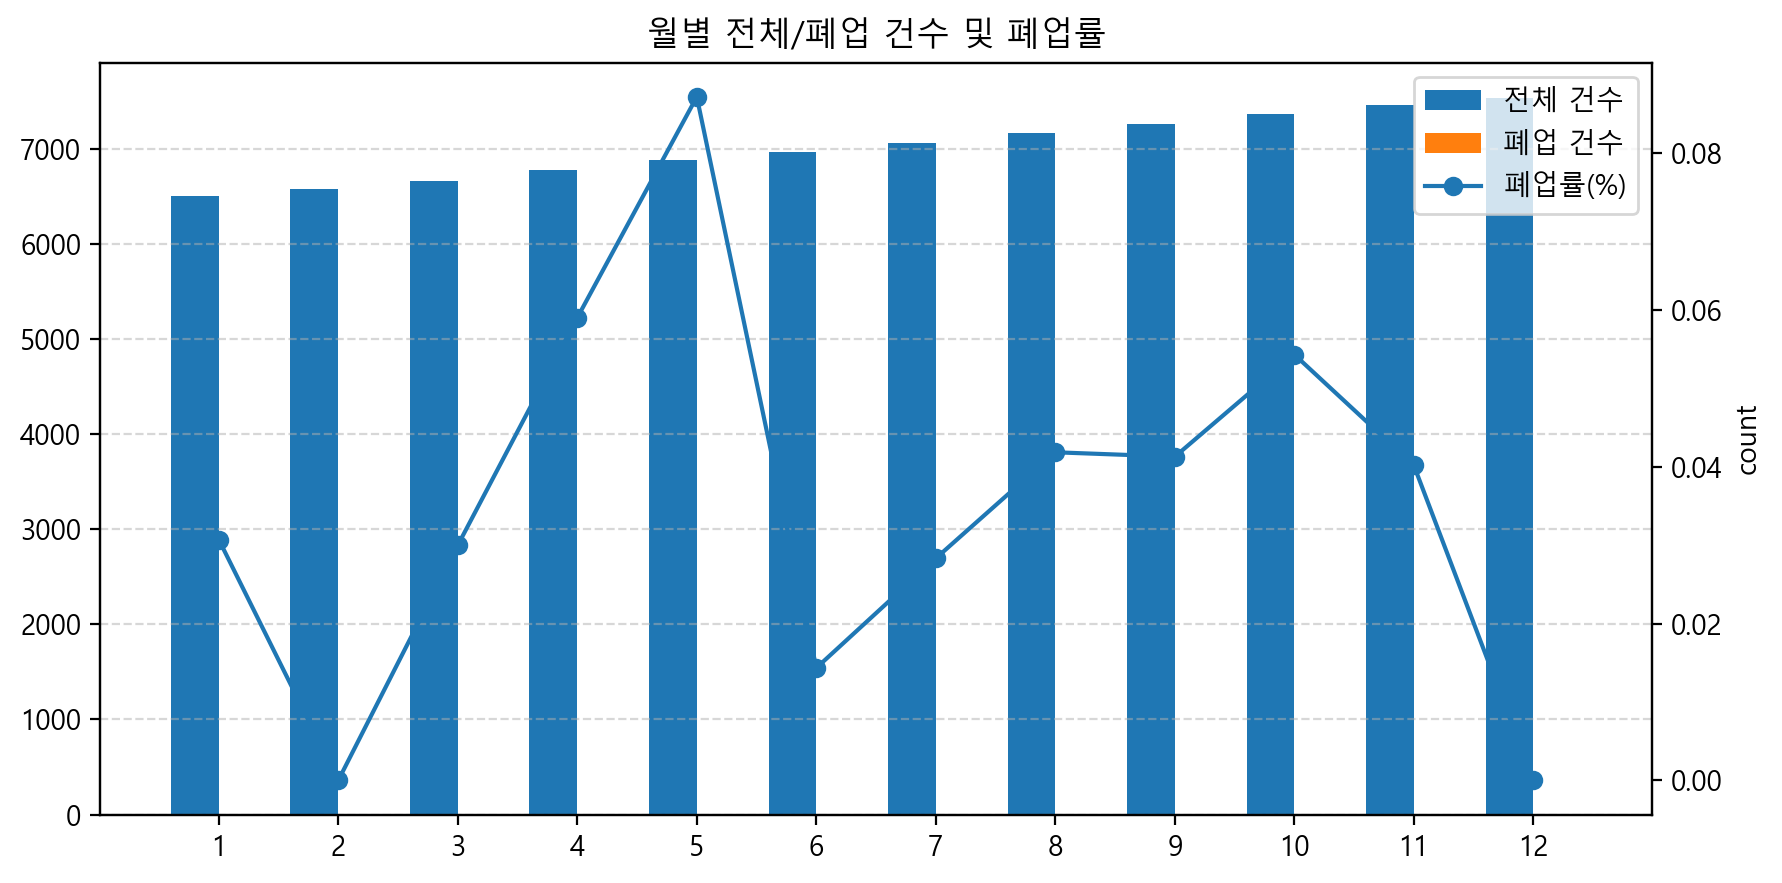

In [17]:
y = pd.to_numeric(df["is_closed_this_month"], errors="coerce").fillna(0).astype(int)

# 월별: 전체/폐업 카운트 + 폐업률 
# month 안전 변환 (1~12만)
m = pd.to_numeric(df.get("month", np.nan), errors="coerce")
m = m.where(m.between(1,12))
month_total = m.value_counts(dropna=True).sort_index()                                   # 전체 건수
month_closed = m[y == 1].value_counts(dropna=True).reindex(month_total.index).fillna(0)  # 폐업 건수
month_rate = (month_closed / month_total.replace(0, np.nan)) * 100                       # 폐업률(%)

x = np.arange(len(month_total))
w = 0.4

plt.figure(figsize=(9,4.5))
# 막대(전체/폐업) — 색 지정 생략
plt.bar(x - w/2, month_total.values, width=w, label="전체 건수")
plt.bar(x + w/2, month_closed.values, width=w, label="폐업 건수")
# 라인(폐업률, 보조축)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(x, month_rate.values, marker="o", linestyle="-", label="폐업률(%)")
ax2.set_ylabel("폐업률(%)")

plt.xticks(x, [str(int(i)) for i in month_total.index])
plt.xlabel("month"); plt.ylabel("count")
plt.title("월별 전체/폐업 건수 및 폐업률")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
# 범례: 두 축의 핸들 결합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
plt.legend(h1+h2, l1+l2, loc="upper right")
plt.tight_layout()
plt.show()

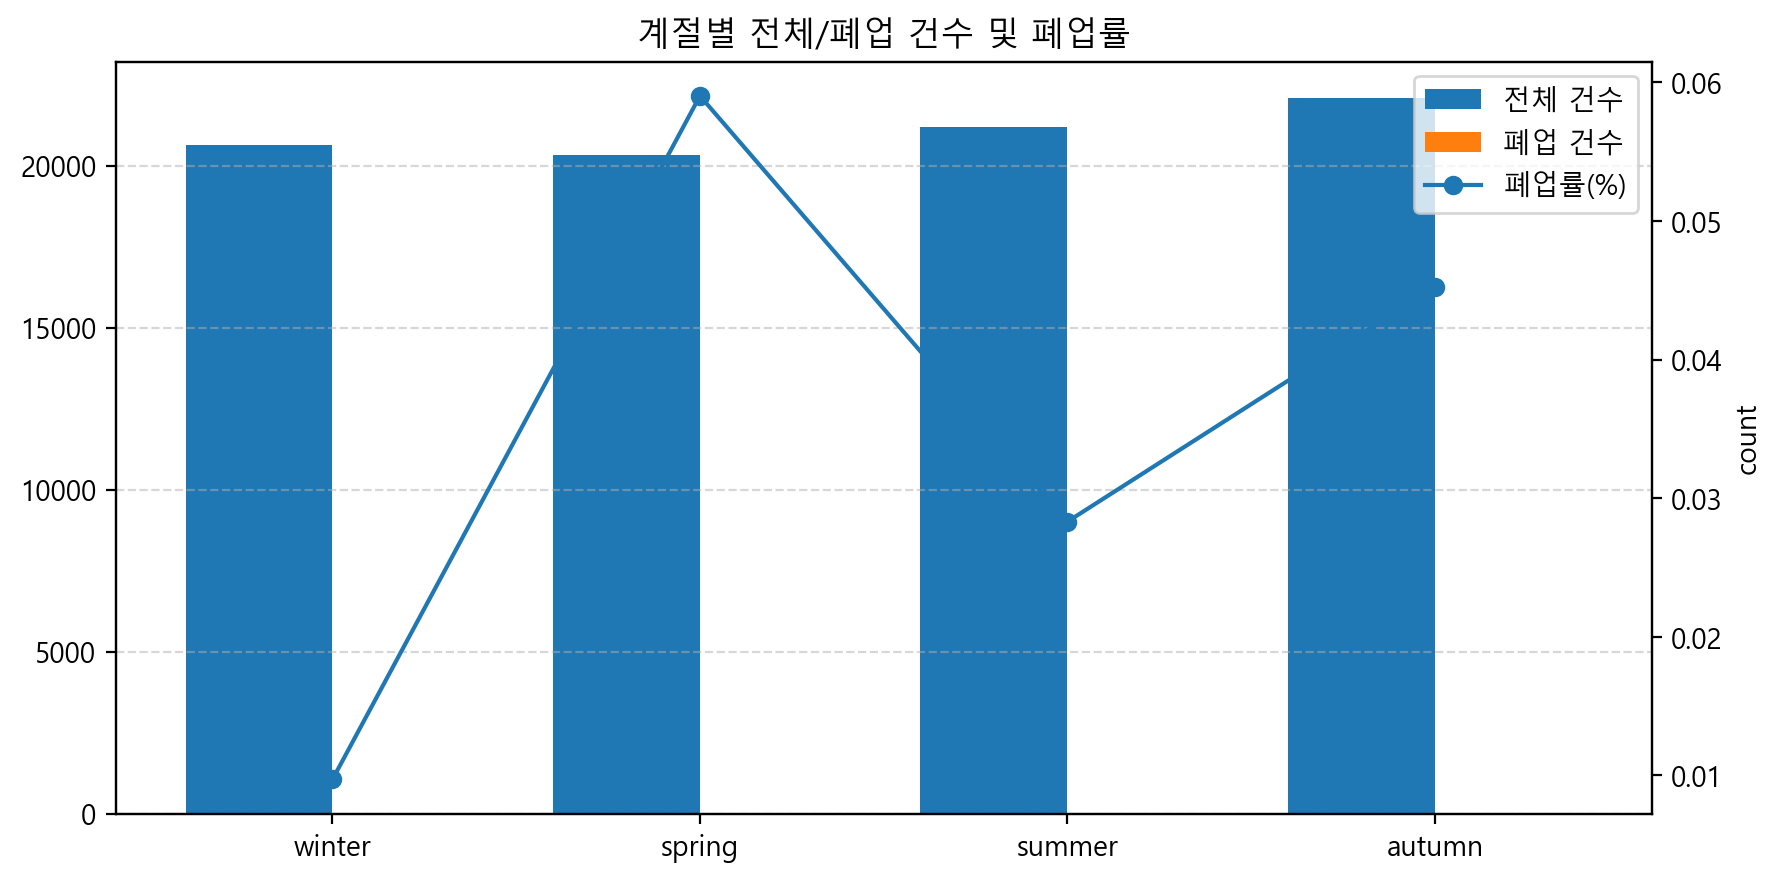

In [18]:
# 계절별: 전체/폐업 카운트 + 폐업률 
season = df.get("season")
season = season.astype(str)
desired_order = ["winter","spring","summer","autumn"]
# 실제 등장한 라벨 기준으로 정렬
s_counts = season.value_counts()
ordered_labels = [s for s in desired_order if s in s_counts.index] + \
                    [s for s in s_counts.index if s not in desired_order]

season_total = season.value_counts().reindex(ordered_labels).fillna(0).astype(int)
season_closed = season[y == 1].value_counts().reindex(ordered_labels).fillna(0).astype(int)
season_rate = (season_closed / season_total.replace(0, np.nan)) * 100

x2 = np.arange(len(season_total))
w2 = 0.4

plt.figure(figsize=(9,4.5))
plt.bar(x2 - w2/2, season_total.values, width=w2, label="전체 건수")
plt.bar(x2 + w2/2, season_closed.values, width=w2, label="폐업 건수")
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(x2, season_rate.values, marker="o", linestyle="-", label="폐업률(%)")
ax2.set_ylabel("폐업률(%)")

plt.xticks(x2, ordered_labels)
plt.xlabel("season"); plt.ylabel("count")
plt.title("계절별 전체/폐업 건수 및 폐업률")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
plt.legend(h1+h2, l1+l2, loc="upper right")
plt.tight_layout()
plt.show()

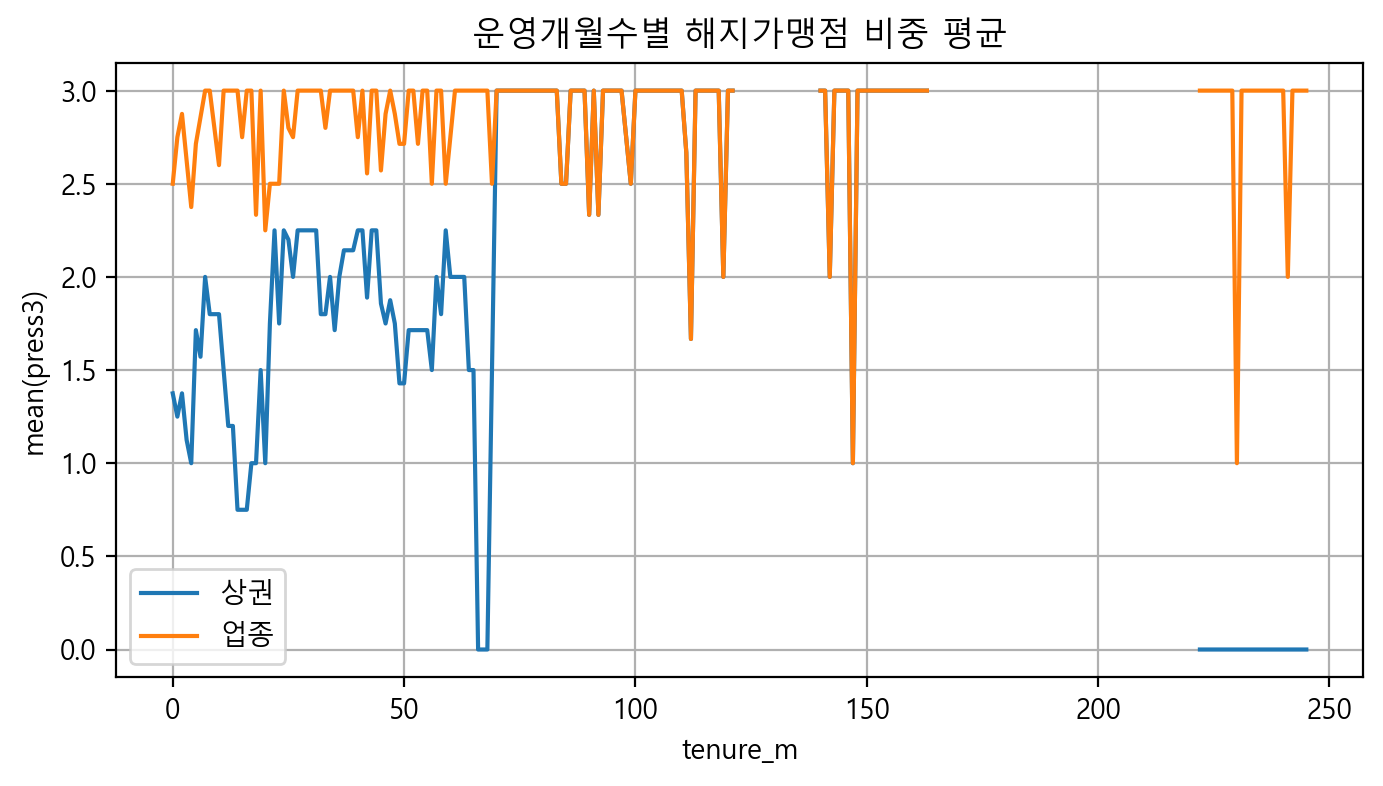

In [19]:
# 3️tenure_m에 따른 해지비중 변화 
tmp = df.groupby("tenure_m")[["동일상권 해지가맹점 비중_press3","동일업종 해지가맹점 비중_press3"]].mean()
plt.figure(figsize=(7,4))
plt.plot(tmp.index, tmp["동일상권 해지가맹점 비중_press3"], label="상권")
plt.plot(tmp.index, tmp["동일업종 해지가맹점 비중_press3"], label="업종")
plt.legend(); plt.grid(True)
plt.title("운영개월수별 해지가맹점 비중 평균")
plt.xlabel("tenure_m"); plt.ylabel("mean(press3)")
plt.tight_layout(); plt.show()